In [1]:
import os
import cv2
import argparse
import numpy as np
import time
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import skew, kurtosis, spearmanr, kendalltau, wasserstein_distance
from skimage.metrics import structural_similarity as ssim
from math import log2
import seaborn as sns
from ImageConstruct import CImageUtils,CImageAlpha,CImageMFS
from DatasetConstruct import CDatasetConstruct
from ImageSimilarity import CImageSimilarity
from ImageDecompose import CImageDecompose
np.set_printoptions(suppress=True, precision=8)

# 读取原始数据

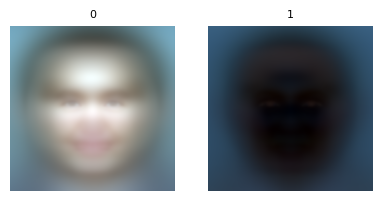

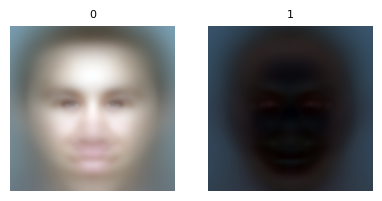

In [2]:
real_mean = CImageUtils.read_image("./images/real-mean.exr")
real_std = CImageUtils.read_image("./images/real-std.exr")
real_mean = cv2.cvtColor(real_mean, cv2.COLOR_BGR2RGB)
real_std = cv2.cvtColor(real_std, cv2.COLOR_BGR2RGB)
CImageUtils.display([real_mean,real_std])
fake_mean = CImageUtils.read_image("./images/fake-mean.exr")
fake_std = CImageUtils.read_image("./images/fake-std.exr")
fake_mean = cv2.cvtColor(fake_mean, cv2.COLOR_BGR2RGB)
fake_std = cv2.cvtColor(fake_std, cv2.COLOR_BGR2RGB)
CImageUtils.display([fake_mean,fake_std])

# 分析mean，选取合适的fade的参数

100%|██████████| 256/256 [00:11<00:00, 21.62it/s]


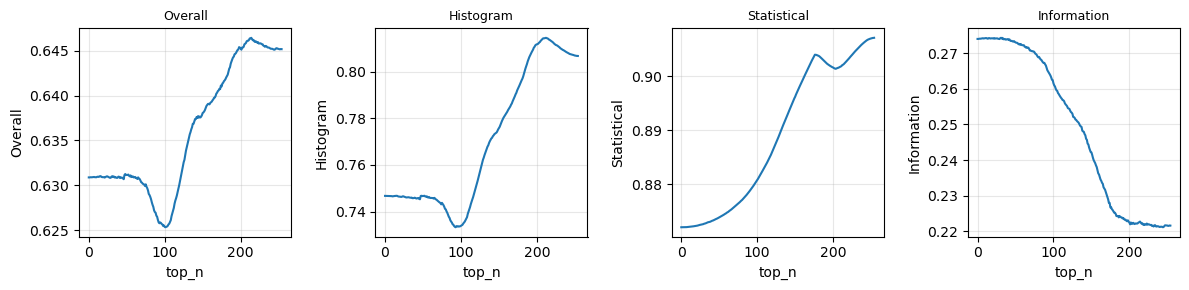

key fade points: [ 21  28  37  46  54  64  74 101 145 147 175 201 244]


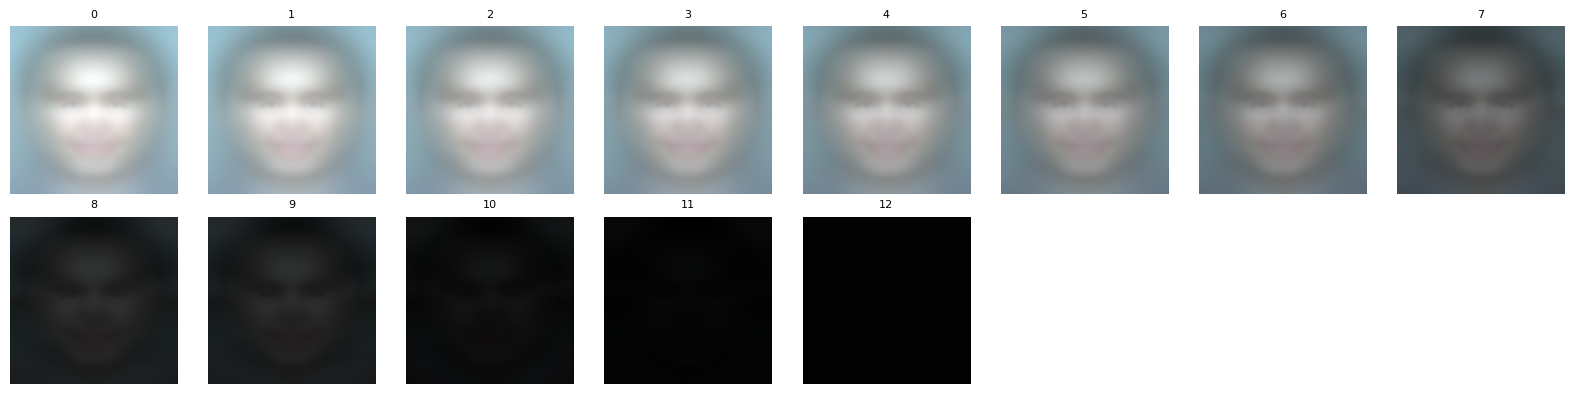

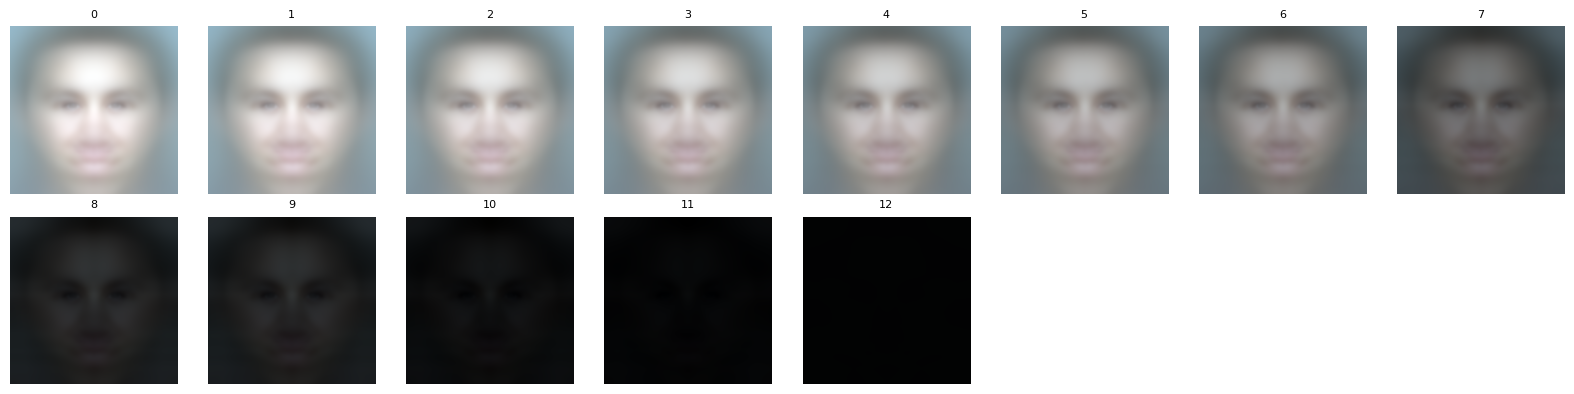

In [16]:
real_svd_mean = CImageDecompose(real_mean).get_svd_auto(count=256)
fake_svd_mean = CImageDecompose(fake_mean).get_svd_auto(count=256)

#不同的real/fake子图的相似度
all_data = []
for real,fake in tqdm(zip(real_svd_mean,fake_svd_mean),total=len(real_svd_mean)):
    if np.sum(real) !=0 :
        metrics = CImageSimilarity(bins=256).compare(real, fake,auto_normalize=True)
        tmp = metrics['score']
        tmp["detail"] = metrics
        all_data.append(tmp)

df_score = pd.DataFrame(all_data)
df_score['top_n'] = df_score.index
ys = ["Overall", "Histogram", "Statistical", "Information"]
CImageSimilarity.display_plots(df_score, x="top_n", ys=ys)

#相似度score的拐点
idx = CImageSimilarity.find_peaks(-df_score['Overall'],prominence=0.0001) 
if len(idx) == 0:
    idx = int(np.argmin(df_svd_mean['Overall']))
    idx = [ idx ]
print("key fade points:",idx)
new_list = [real_svd_mean[i] for i in idx]
CImageUtils.display(new_list)
new_list = [fake_svd_mean[i] for i in idx]
CImageUtils.display(new_list)

# 分析std图，选取合适的fade的参数

100%|██████████| 256/256 [00:12<00:00, 21.09it/s]


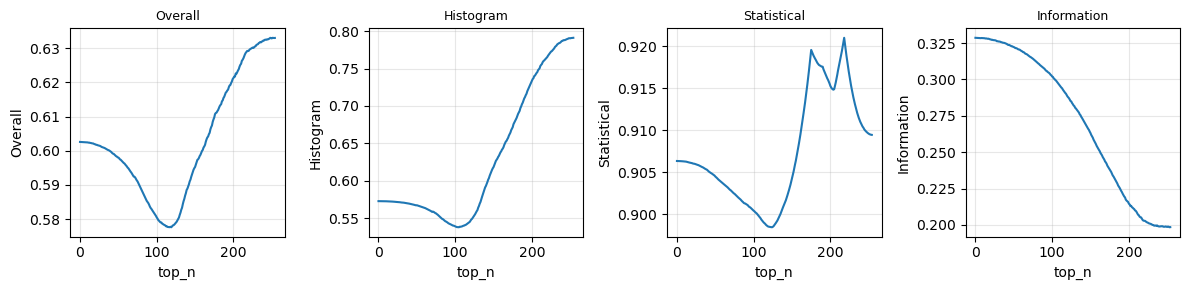

key fade points: [117 119 226 250]


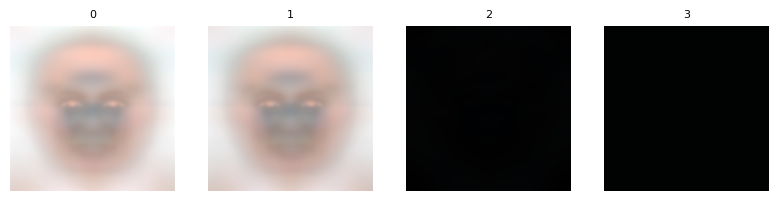

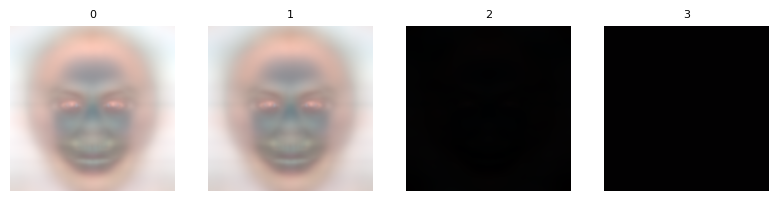

In [17]:
real_svd_std = CImageDecompose(real_std).get_svd_auto(count=256)
fake_svd_std = CImageDecompose(fake_std).get_svd_auto(count=256)

#不同的real/fake子图的相似度
all_data = []
for real,fake in tqdm(zip(real_svd_std,fake_svd_std),total=len(real_svd_std)):
    if np.sum(real) !=0 :
        metrics = CImageSimilarity(bins=256).compare(real, fake,auto_normalize=True)
        tmp = metrics['score']
        tmp["detail"] = metrics
        all_data.append(tmp)

df_score = pd.DataFrame(all_data)
df_score['top_n'] = df_score.index
ys = ["Overall", "Histogram", "Statistical", "Information"]
CImageSimilarity.display_plots(df_score, x="top_n", ys=ys)

#相似度score的拐点
idx = CImageSimilarity.find_peaks(-df_score['Overall'],prominence=0.0001) 
if len(idx) == 0:
    idx = int(np.argmin(df_svd_mean['Overall']))
    idx = [ idx ]
print("key fade points:",idx)
new_list = [real_svd_std[i] for i in idx]
CImageUtils.display(new_list)
new_list = [fake_svd_std[i] for i in idx]
CImageUtils.display(new_list)

# Local alpha

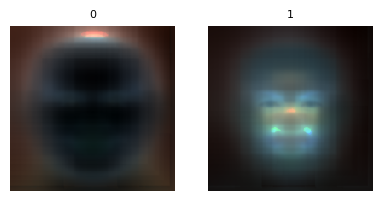

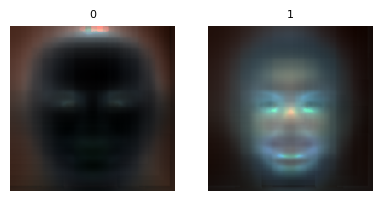

In [3]:
real_alpha_mean = CImageAlpha(real_mean).get_raw_alpha()
real_alpha_std = CImageAlpha(real_std).get_raw_alpha()
fake_alpha_mean = CImageAlpha(fake_mean).get_raw_alpha()
fake_alpha_std = CImageAlpha(fake_std).get_raw_alpha()
CImageUtils.display([real_alpha_mean,real_alpha_std])
CImageUtils.display([fake_alpha_mean,fake_alpha_std])

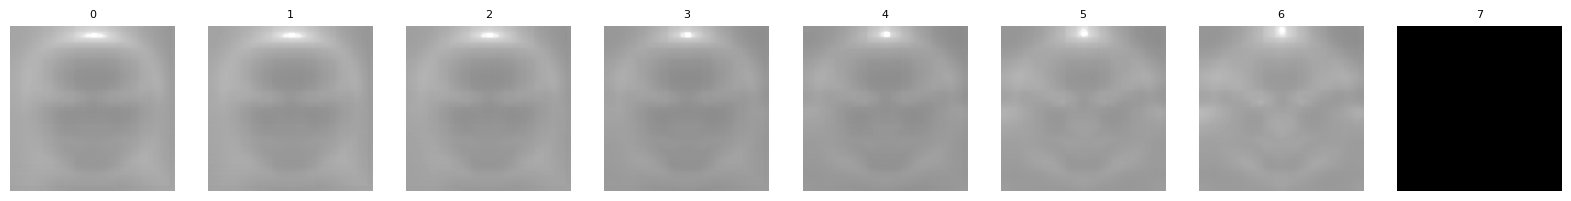

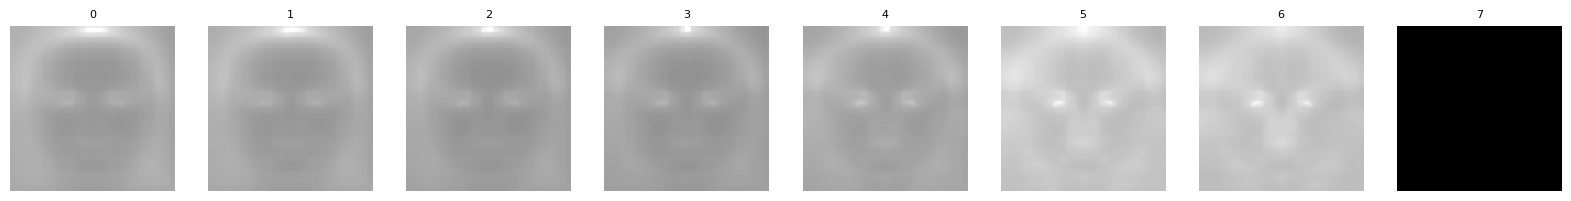

In [4]:
real_gray = CImageAlpha(real_mean).get_gray_alpha(count=8)
fake_gray = CImageAlpha(fake_mean).get_gray_alpha(count=8)
CImageUtils.display(real_gray)
CImageUtils.display(fake_gray)

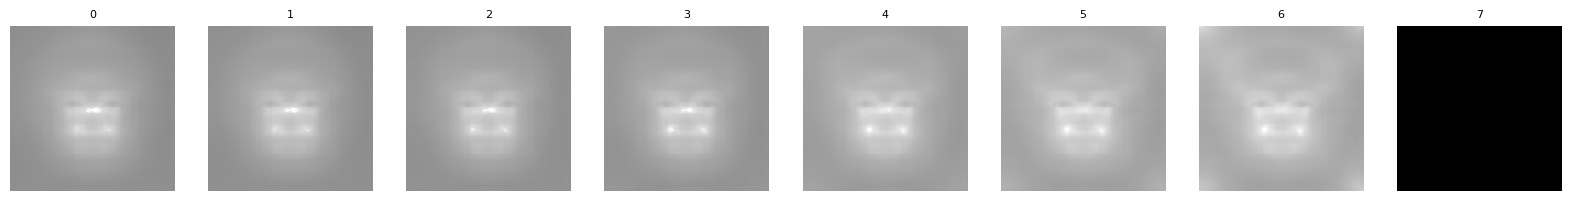

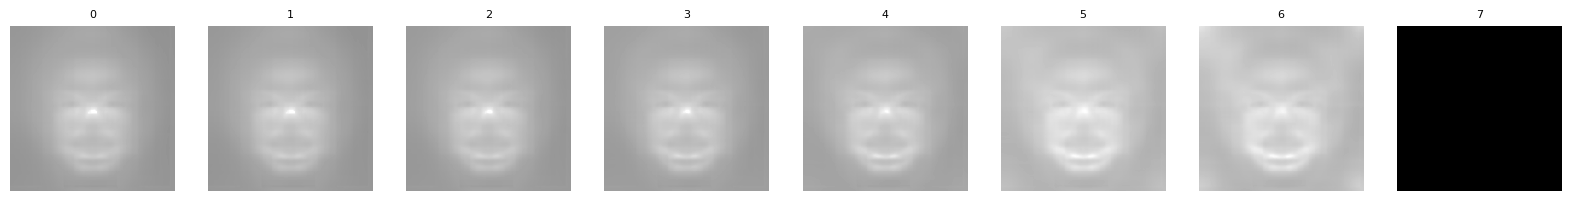

In [5]:
real_gray = CImageAlpha(real_std).get_gray_alpha(count=8)
fake_gray = CImageAlpha(fake_std).get_gray_alpha(count=8)
CImageUtils.display(real_gray)
CImageUtils.display(fake_gray)

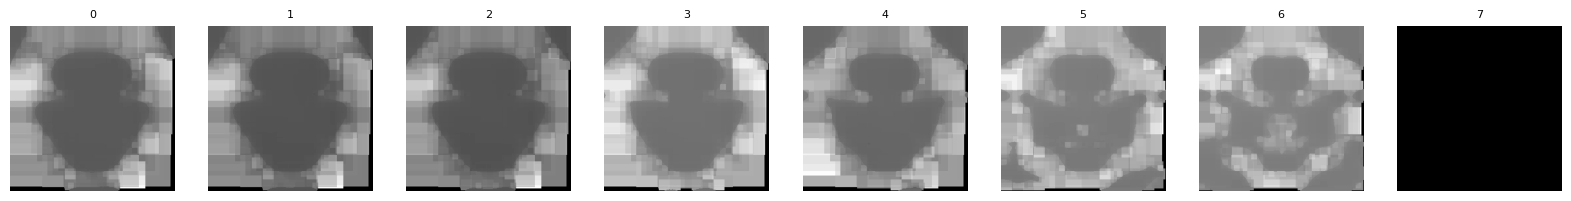

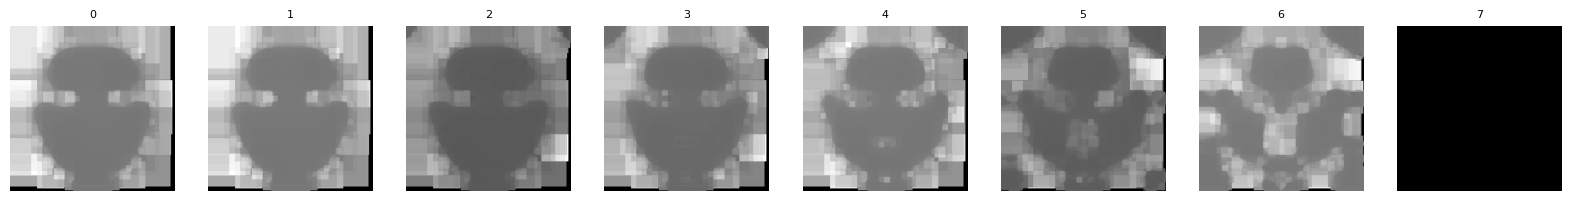

In [6]:
real_bin = CImageAlpha(real_mean).get_bin_alpha(count=8)
fake_bin = CImageAlpha(fake_mean).get_bin_alpha(count=8)
CImageUtils.display(real_bin)
CImageUtils.display(fake_bin)

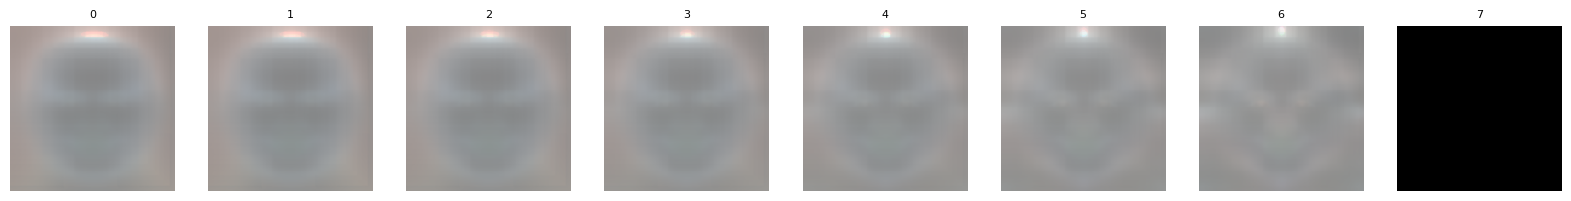

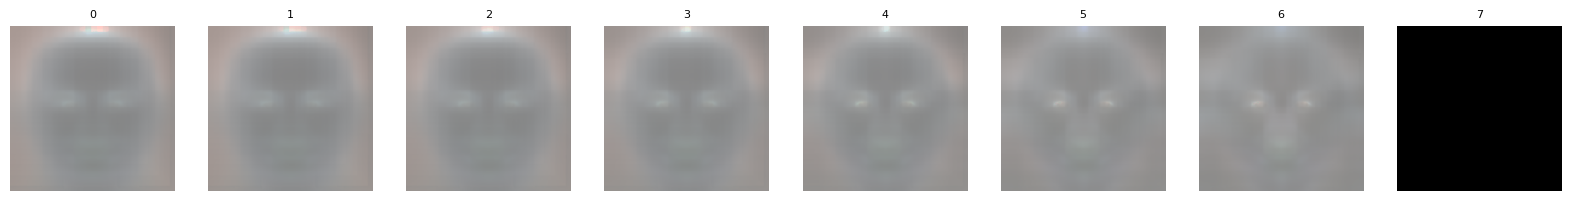

In [7]:
real_svd = CImageAlpha(real_mean).get_svd_alpha(count=8)
fake_svd = CImageAlpha(fake_mean).get_svd_alpha(count=8)
CImageUtils.display(real_svd)
CImageUtils.display(fake_svd)

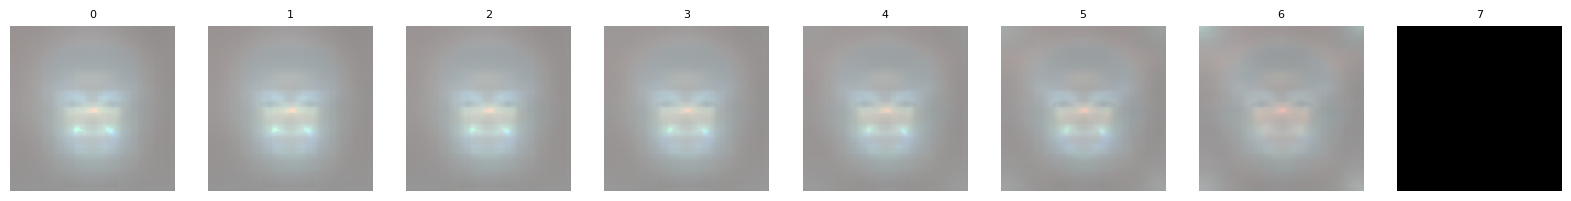

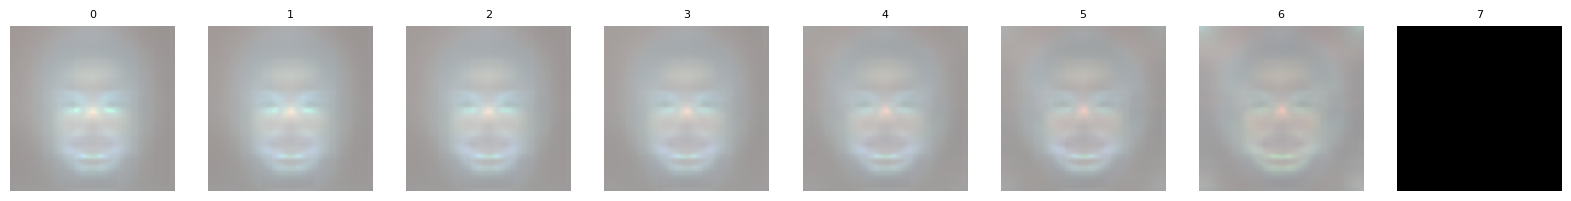

In [8]:
real_svd = CImageAlpha(real_std).get_svd_alpha(count=8)
fake_svd = CImageAlpha(fake_std).get_svd_alpha(count=8)
CImageUtils.display(real_svd)
CImageUtils.display(fake_svd)

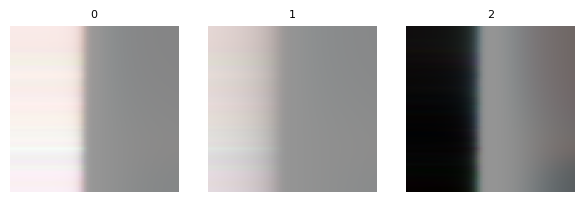

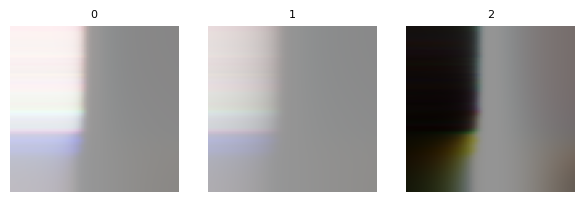

In [3]:
real_img_mfs = CImageMFS(real_mean,count = 64).get_image_mfs()
fake_img_mfs = CImageMFS(fake_mean,count = 64).get_image_mfs()
real_img_mfs = CImageUtils.normalize_by_channel(np.array(real_img_mfs))
fake_img_mfs = CImageUtils.normalize_by_channel(np.array(fake_img_mfs))
CImageUtils.display(real_img_mfs)
CImageUtils.display(fake_img_mfs)

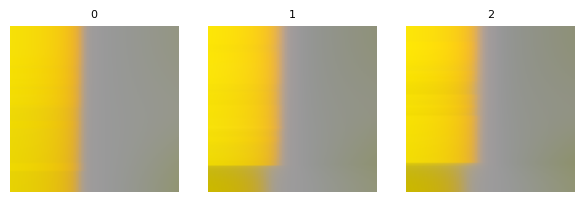

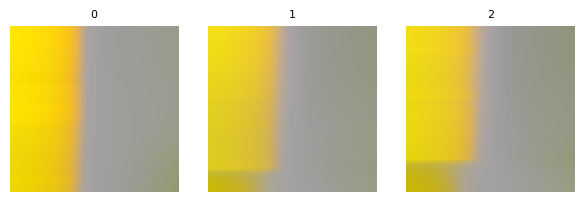

In [4]:
real_mfs_img = CImageMFS(real_std,count = 64).get_mfs_image()
fake_mfs_img = CImageMFS(fake_std,count = 64).get_mfs_image()
real_mfs_img = CImageUtils.normalize_by_channel(np.array(real_mfs_img))
fake_mfs_img = CImageUtils.normalize_by_channel(np.array(fake_mfs_img))
CImageUtils.display(real_mfs_img)
CImageUtils.display(fake_mfs_img)